Train RFs to predict TCR-pMHC interactions based on scores

Note: MHC-I: (1) MHC, (2) peptide, (3) TCRA, (4) TCRB --> MHC-I: (0) MHC, (1) peptide, (2) TCRA, (3) TCRB

In [1]:
import numpy as np
import pandas as pd
from dataclasses import dataclass
from typing import List, Dict, Any, Optional

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
    f1_score,
    recall_score
)

@dataclass
class RFEnsembleResult:
    models: List[RandomForestClassifier]
    metrics: pd.DataFrame
    feature_importances: pd.DataFrame
    mean_auc: float
    std_auc: float
    mean_acc: float
    std_acc: float
        
def train_rf_ensemble_auc(
    df: pd.DataFrame,
    features: List[str],
    label_col: str = "positive",
    n_runs: int = 100,
    test_size: float = 0.2,
    base_seed: int = 1,
    rf_params: Optional[Dict[str, Any]] = None,
    plot: bool = True,
) -> RFEnsembleResult:

    missing = [c for c in features + [label_col] if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns in df: {missing}")

    X = df[features].copy()
    y = df[label_col].astype(int).copy()
    # {0: 1, 1: 10} / "balanced"
    default_rf_params = dict(
        n_estimators=2000,
        class_weight={0: 1, 1: 20},
        n_jobs=-1,
    )
    if rf_params:
        default_rf_params.update(rf_params)

    models = []
    rows_metrics = []
    rows_importances = []

    for i in range(n_runs):
        seed = base_seed + i

        X_train, X_test, y_train, y_test = train_test_split(
            X, y,
            test_size=test_size,
            random_state=seed,
            stratify=y
        )

        rf = RandomForestClassifier(random_state=seed, **default_rf_params)
        rf.fit(X_train, y_train)

        y_pred = rf.predict(X_test)
        y_proba = rf.predict_proba(X_test)[:, 1]

        # --- Standard metrics ---
        acc = accuracy_score(y_test, y_pred)
        auc_val = roc_auc_score(y_test, y_proba)

        # --- New metrics ---
        recall = recall_score(y_test, y_pred)
        fnr = 1 - recall
        f1 = f1_score(y_test, y_pred)
        pr_auc = average_precision_score(y_test, y_proba)

        rows_metrics.append({
            "run": i,
            "seed": seed,
            "auc": auc_val,
            "acc": acc,
            "recall": recall,
            "fnr": fnr,
            "f1": f1,
            "pr_auc": pr_auc,
            "n_test_pos": int((y_test == 1).sum()),
            "n_test_neg": int((y_test == 0).sum()),
        })

        rows_importances.append(
            pd.Series(rf.feature_importances_, index=features, name=i)
        )

        models.append(rf)

    metrics = pd.DataFrame(rows_metrics).sort_values("run").reset_index(drop=True)
    importances = pd.DataFrame(rows_importances).sort_index()

    # --- Aggregate metrics ---
    agg = metrics.mean(numeric_only=True)

    print("Runs:", n_runs)
    print(f"Mean AUC:     {agg['auc']:.3f}")
    print(f"Mean Acc:     {agg['acc']:.3f}")
    print(f"Mean Recall:  {agg['recall']:.3f}")
    print(f"Mean FNR:     {agg['fnr']:.3f}")
    print(f"Mean F1:      {agg['f1']:.3f}")
    print(f"Mean PR-AUC:  {agg['pr_auc']:.3f}")

    if plot:
        # --- Feature importance plot ---
        imp_mean = importances.mean(axis=0).sort_values(ascending=False)

        plt.figure(figsize=(6, 4))
        sns.barplot(x=imp_mean.values, y=imp_mean.index)
        plt.title("Mean Feature Importance")
        plt.tight_layout()
        plt.show()

        # --- Plot distribution of AUCs across runs ---
        plt.figure(figsize=(6, 4))
        sns.histplot(metrics["auc"], bins=15, kde=True)
        plt.xlabel("AUC")
        plt.ylabel("Count")
        plt.title("Distribution of AUC Across Ensemble Runs")
        plt.tight_layout()
        plt.savefig("figures/AUC_RF.pdf", format="pdf")
        plt.show()

        # Optional: boxplot version
        plt.figure(figsize=(4, 4))
        sns.boxplot(y=metrics["auc"])
        plt.ylabel("AUC")
        plt.title("AUC Variation Across Runs")
        plt.tight_layout()
        plt.show()


    return RFEnsembleResult(
        models=models,
        metrics=metrics,
        feature_importances=importances,
        mean_auc=float(agg["auc"]),
        std_auc=float(metrics["auc"].std(ddof=1)),
        mean_acc=float(agg["acc"]),
        std_acc=float(metrics["acc"].std(ddof=1)),
    )


In [2]:
def train_rf_ensemble_auc(
    df: pd.DataFrame,
    features: List[str],
    label_col: str = "positive",
    n_runs: int = 100,
    test_size: float = 0.2,
    base_seed: int = 1,
    rf_params: Optional[Dict[str, Any]] = None,
    target_recall: float = 0.80,
    plot: bool = True,
) -> RFEnsembleResult:

    missing = [c for c in features + [label_col] if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns in df: {missing}")

    X = df[features].copy()
    y = df[label_col].astype(int).copy()
# {0: 1, 1: 20}
    default_rf_params = dict(
        n_estimators=2000,
        class_weight="balanced",
        n_jobs=-1,
    )
    if rf_params:
        default_rf_params.update(rf_params)

    models = []
    rows_metrics = []
    rows_importances = []
    thresholds_used = []

    for i in range(n_runs):
        seed = base_seed + i

        X_train, X_test, y_train, y_test = train_test_split(
            X, y,
            test_size=test_size,
            random_state=seed,
            stratify=y
        )

        rf = RandomForestClassifier(random_state=seed, **default_rf_params)
        rf.fit(X_train, y_train)

        y_proba = rf.predict_proba(X_test)[:, 1]

        # --- Compute PR curve for threshold tuning ---
        precision, recall_curve, thresholds = precision_recall_curve(y_test, y_proba)

        # thresholds array is len-1 compared to recall/precision
        thresholds = np.append(thresholds, 1.0)

        # find smallest threshold achieving target recall
        idx = np.where(recall_curve >= target_recall)[0]
        if len(idx) == 0:
            tuned_threshold = 0.0
        else:
            tuned_threshold = thresholds[idx[-1]]

        thresholds_used.append(tuned_threshold)

        # apply tuned threshold
        y_pred = (y_proba >= tuned_threshold).astype(int)

        # --- Metrics at tuned threshold ---
        acc = accuracy_score(y_test, y_pred)
        auc_val = roc_auc_score(y_test, y_proba)
        recall = recall_score(y_test, y_pred)
        fnr = 1 - recall
        f1 = f1_score(y_test, y_pred)
        pr_auc = average_precision_score(y_test, y_proba)

        rows_metrics.append({
            "run": i,
            "seed": seed,
            "threshold": tuned_threshold,
            "auc": auc_val,
            "acc": acc,
            "recall": recall,
            "fnr": fnr,
            "f1": f1,
            "pr_auc": pr_auc,
            "n_test_pos": int((y_test == 1).sum()),
            "n_test_neg": int((y_test == 0).sum()),
        })

        rows_importances.append(
            pd.Series(rf.feature_importances_, index=features, name=i)
        )

        models.append(rf)

    metrics = pd.DataFrame(rows_metrics).sort_values("run").reset_index(drop=True)
    importances = pd.DataFrame(rows_importances).sort_index()

    agg = metrics.mean(numeric_only=True)

    print("Runs:", n_runs)
    print(f"Target Recall: {target_recall}")
    print(f"Mean Tuned Threshold: {agg['threshold']:.3f}")
    print(f"Mean AUC:     {agg['auc']:.3f}")
    print(f"Mean Acc:     {agg['acc']:.3f}")
    print(f"Mean Recall:  {agg['recall']:.3f}")
    print(f"Mean FNR:     {agg['fnr']:.3f}")
    print(f"Mean F1:      {agg['f1']:.3f}")
    print(f"Mean PR-AUC:  {agg['pr_auc']:.3f}")

    if plot:
        imp_mean = importances.mean(axis=0).sort_values(ascending=False)

        plt.figure(figsize=(6, 4))
        sns.barplot(x=imp_mean.values, y=imp_mean.index)
        plt.title("Mean Feature Importance")
        plt.tight_layout()
        plt.show()
        
        # --- Plot distribution of AUCs across runs ---
                # --- ROC curves for all runs ---
        plt.figure(figsize=(6, 6))

        all_fpr = np.linspace(0, 1, 200)
        tprs = []

        for i in range(n_runs):
            # Recompute ROC for each run
            seed = base_seed + i

            X_train, X_test, y_train, y_test = train_test_split(
                X, y,
                test_size=test_size,
                random_state=seed,
                stratify=y
            )

            rf = models[i]
            y_proba = rf.predict_proba(X_test)[:, 1]

            fpr, tpr, _ = roc_curve(y_test, y_proba)
            auc_val = metrics.loc[i, "auc"]

            # Plot individual ROC curve
            plt.plot(fpr, tpr, alpha=0.15, color="steelblue")

            # Interpolate for mean curve
            tpr_interp = np.interp(all_fpr, fpr, tpr)
            tpr_interp[0] = 0.0
            tprs.append(tpr_interp)

        # Mean ROC curve
        mean_tpr = np.mean(tprs, axis=0)
        mean_tpr[-1] = 1.0
        mean_auc = metrics["auc"].mean()

        plt.plot(all_fpr, mean_tpr, color="darkred", lw=2,
                 label=f"Mean ROC (AUC = {mean_auc:.3f})")

        plt.plot([0, 1], [0, 1], "k--", lw=1)
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("ROC Curves Across Ensemble Runs")
        plt.legend()
        plt.tight_layout()
        plt.savefig("figures/ROC_RF.pdf", format="pdf")
        plt.show()



    return RFEnsembleResult(
        models=models,
        metrics=metrics,
        feature_importances=importances,
        mean_auc=float(agg["auc"]),
        std_auc=float(metrics["auc"].std(ddof=1)),
        mean_acc=float(agg["acc"]),
        std_acc=float(metrics["acc"].std(ddof=1)),
    )


In [3]:
df_full = pd.read_csv("dt/combined_BEAM_with_inSilicoNegatives.csv")

/tmp/ipykernel_815399/2095343556.py:1: DtypeWarning: Columns (69,75,83,85,86) have mixed types. Specify dtype option on import or set low_memory=False.
  df_full = pd.read_csv("dt/combined_BEAM_with_inSilicoNegatives.csv")


In [4]:
df_full['type'].value_counts()

type
negative_binder    7730
binder             1921
peptide             670
MHC                 335
randomized          335
negative              1
Name: count, dtype: int64

In [5]:
df1 = pd.read_csv("dt/combined_HIV_CMV_HPV_and_randomised_peptides_w_pae.csv", index_col = 0)

In [6]:
df_full = pd.concat([df1,df_full])

In [7]:
df_full = df_full.sample(frac=1, random_state=42).reset_index(drop=True)


In [8]:
df_full.to_csv("dt/combined_BEAM_with_inSilicoNegatives_w_HIV_CMV_HPV.csv",index = None)

In [8]:
# features = ["pmhc_tcr_pae", "model_2_ptm_ft4_plddt"]
# res_af2 = train_rf_ensemble_auc(df_full, features, label_col="positive", n_runs=100, plot=True)



In [9]:
# res_af2.mean_auc, res_af2.std_auc
# res_af2.metrics.head()
# # len(res_af2.models) 

In [10]:
# df_full = pd.read_csv("dt/combined_BEAM_with_inSilicoNegatives.csv")

Runs: 100
Target Recall: 0.8
Mean Tuned Threshold: 0.218
Mean AUC:     0.910
Mean Acc:     0.856
Mean Recall:  0.802
Mean FNR:     0.198
Mean F1:      0.703
Mean PR-AUC:  0.812


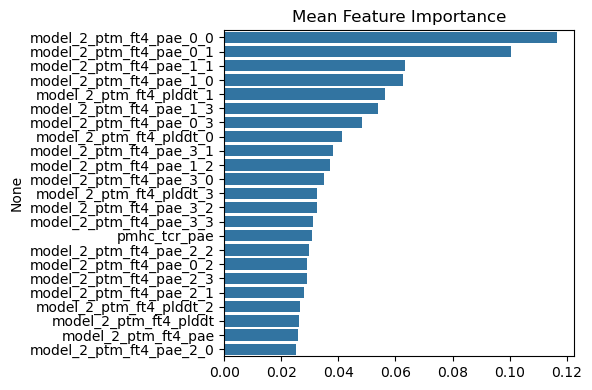

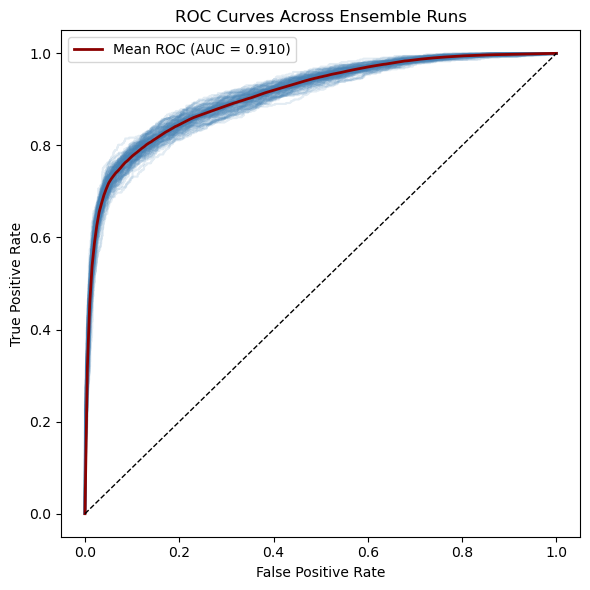

100

In [11]:
features = ["pmhc_tcr_pae", "model_2_ptm_ft4_plddt",'model_2_ptm_ft4_pae', 'model_2_ptm_ft4_plddt_0',
       'model_2_ptm_ft4_pae_0_0', 'model_2_ptm_ft4_pae_0_1',
       'model_2_ptm_ft4_pae_0_2', 'model_2_ptm_ft4_pae_0_3',
       'model_2_ptm_ft4_plddt_1', 'model_2_ptm_ft4_pae_1_0',
       'model_2_ptm_ft4_pae_1_1', 'model_2_ptm_ft4_pae_1_2',
       'model_2_ptm_ft4_pae_1_3', 'model_2_ptm_ft4_plddt_2',
       'model_2_ptm_ft4_pae_2_0', 'model_2_ptm_ft4_pae_2_1',
       'model_2_ptm_ft4_pae_2_2', 'model_2_ptm_ft4_pae_2_3',
       'model_2_ptm_ft4_plddt_3', 'model_2_ptm_ft4_pae_3_0',
       'model_2_ptm_ft4_pae_3_1', 'model_2_ptm_ft4_pae_3_2',
       'model_2_ptm_ft4_pae_3_3',]
res_af2_v2 = train_rf_ensemble_auc(df_full, features, label_col="positive", n_runs=100, plot=True)

# Access results
res_af2_v2.mean_auc, res_af2_v2.std_auc
res_af2_v2.metrics.head()
len(res_af2_v2.models)  

In [12]:
res_af2_v2.metrics.head()

,run,seed,threshold,auc,acc,recall,fnr,f1,pr_auc,n_test_pos,n_test_neg
0,0,1,0.204000,0.911355,0.843393,0.801541,0.198459,0.684211,0.809497,519,1933
1,1,2,0.201101,0.908956,0.837276,0.801541,0.198459,0.675873,0.814745,519,1933
2,2,3,0.213055,0.907389,0.841762,0.801541,0.198459,0.681967,0.809854,519,1933
3,3,4,0.213500,0.913547,0.861746,0.801541,0.198459,0.710504,0.821744,519,1933
4,4,5,0.211500,0.912361,0.861746,0.801541,0.198459,0.710504,0.812884,519,1933


In [13]:
from pathlib import Path
import joblib
import json

def save_rf_ensemble(result: RFEnsembleResult, features, out_prefix: str):
    out_prefix = Path(out_prefix)
    out_prefix.parent.mkdir(parents=True, exist_ok=True)

    # save models (list of RandomForestClassifier)
    joblib.dump(result.models, out_prefix.with_suffix(".joblib"))

    # save metadata + metrics/importances
    meta = {"features": list(features)}
    (out_prefix.with_suffix(".meta.json")).write_text(json.dumps(meta, indent=2))

    result.metrics.to_csv(out_prefix.with_suffix(".metrics.csv"), index=False)
    result.feature_importances.to_csv(out_prefix.with_suffix(".importances.csv"), index=True)

In [14]:
# save_rf_ensemble(res_af2, features=["pmhc_tcr_pae", "model_2_ptm_ft4_plddt"], out_prefix="dt_out/res_af2")

save_rf_ensemble(res_af2_v2, features=["pmhc_tcr_pae", "model_2_ptm_ft4_plddt",'model_2_ptm_ft4_pae', 'model_2_ptm_ft4_plddt_0',
       'model_2_ptm_ft4_pae_0_0', 'model_2_ptm_ft4_pae_0_1',
       'model_2_ptm_ft4_pae_0_2', 'model_2_ptm_ft4_pae_0_3',
       'model_2_ptm_ft4_plddt_1', 'model_2_ptm_ft4_pae_1_0',
       'model_2_ptm_ft4_pae_1_1', 'model_2_ptm_ft4_pae_1_2',
       'model_2_ptm_ft4_pae_1_3', 'model_2_ptm_ft4_plddt_2',
       'model_2_ptm_ft4_pae_2_0', 'model_2_ptm_ft4_pae_2_1',
       'model_2_ptm_ft4_pae_2_2', 'model_2_ptm_ft4_pae_2_3',
       'model_2_ptm_ft4_plddt_3', 'model_2_ptm_ft4_pae_3_0',
       'model_2_ptm_ft4_pae_3_1', 'model_2_ptm_ft4_pae_3_2',
       'model_2_ptm_ft4_pae_3_3',], out_prefix="dt_out/res_af2_v2_lowFNR")


In [15]:
!date

Wed Feb 25 15:57:51 GMT 2026
